# NHE6/TBC1D5 model preparation

The AF model has many unmodeled loops. Let's remove them.

1. Find continuous stretches that do not have secondary structure and high (bad) scores (in beta field)
2. Remove these stretches.

## packages

In [2]:
import warnings
import pathlib

import numpy as np
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import dssp

Install [tabulate](https://pypi.org/project/tabulate/) for nice tables.

In [3]:
import tabulate

## data

In [ ]:
model = pathlib.Path("./PDBmodel_0.pdb")

In [5]:
u = mda.Universe(model)
protein = u.select_atoms("protein")

In [6]:
print(protein.segments)

<SegmentGroup [<Segment A>, <Segment B>, <Segment C>, <Segment D>, <Segment E>, <Segment F>]>


In [7]:
[s.residues.n_residues for s in protein.segments]

[701, 701, 817, 817, 207, 207]

In [8]:
chains = protein.groupby("segids")
chains

{'C': <AtomGroup with 6412 atoms>,
 'E': <AtomGroup with 1651 atoms>,
 'F': <AtomGroup with 1651 atoms>,
 'D': <AtomGroup with 6412 atoms>,
 'A': <AtomGroup with 5492 atoms>,
 'B': <AtomGroup with 5492 atoms>}

Build masks on the whole `protein` ag to be able to extract data from an array of shape `protein` by segid.

In [9]:
chain_masks = {chainid: np.isin(protein.ix, chain.ix) for chainid, chain in chains.items()}
chain_masks

{'C': array([False, False, False, ..., False, False, False], shape=(27110,)),
 'E': array([False, False, False, ..., False, False, False], shape=(27110,)),
 'F': array([False, False, False, ...,  True,  True,  True], shape=(27110,)),
 'D': array([False, False, False, ..., False, False, False], shape=(27110,)),
 'A': array([ True,  True,  True, ..., False, False, False], shape=(27110,)),
 'B': array([False, False, False, ..., False, False, False], shape=(27110,))}

In [10]:
chain_residue_masks = {chainid: np.isin(protein.residues.ix, chain.residues.ix) for chainid, chain in chains.items()}
chain_residue_masks

{'C': array([False, False, False, ..., False, False, False], shape=(3450,)),
 'E': array([False, False, False, ..., False, False, False], shape=(3450,)),
 'F': array([False, False, False, ...,  True,  True,  True], shape=(3450,)),
 'D': array([False, False, False, ..., False, False, False], shape=(3450,)),
 'A': array([ True,  True,  True, ..., False, False, False], shape=(3450,)),
 'B': array([False, False, False, ..., False, False, False], shape=(3450,))}

## Functions

These functions are needed for the workflow.

In [13]:
def define_loop_stretches(loops, offset=0):
    """Describe stretches of ``True`` in `loops` by ``(start, stop)`` slices.

    Arguments
    ---------
    loops : bool array
            For each residue, True indicates "loop". 
            Provide for a chain.
    offset : int
            index of first residue in full protein atomgroup;
            This should be a residue.ix index into the **full** 
            universe!

    Returns
    -------
    start, stop : array, array
            start residue indices (inclusive, based on underlying Universe) array
            and stop residue indices (exclusive)


    Example
    -------
    In this example, `loops` is generated for the *whole protein* and then we use
    the residue indices to pull out the part corresponding to the chain A::

      protein = u.select_atoms("protein")
      loops = DSSP(protein).run().results.dssp_ndarray[0, :, 0]
      A = protein.select_atoms("chainID A")
      first_resix, last_resix = A.residues[0].ix, A.residues[-1].ix
      start, stop = define_loop_stretches(loops[first_resix:last_resix + 1], offset=first_resix)

      first_loop = u.residues[start[0]:stop[0]]
    """
    
    first = 0
    last = len(loops)

    sloops = loops.astype(np.int8)
    d = np.diff(sloops)
    e = np.where(d < 0)[0]
    b = np.where(d > 0)[0] + 1
    
    if b[0] > e[0]:
        # starting with a loop
        start = np.concat([[first], b])
    else:
        start = b.copy()
    
    stop = e + 1
    if b[-1] > e[-1]:
        # end with a loop
        stop = np.concat([stop, [last]])
    
    #print(start.shape, stop.shape)
    return start + offset, stop + offset

def loop_stretches(ag, loops):
    """Get the (start, stop) for loop stretches.

    Arguments
    ---------
    ag : AtomGroup
            Get loops that are inside ag
    loops : array
         Boolean array with True for a loop residue.
         Has to be defined for the *whole universe*
         because we use the MDA residue indices from `ag`
         to find the corresponding segments in `loops`.
    """
    first_resix, last_resix = ag.residues[0].ix, ag.residues[-1].ix
    #print(ag, first_resix, last_resix)
    return define_loop_stretches(loops[first_resix:last_resix + 1], offset=first_resix)
    

## development of workflow for trimming to reliable model

Select protein (there are also GTP and MG in the model)

### DSSP

In [36]:
protein = u.select_atoms("protein")
dssp_analysis = dssp.DSSP(protein).run()

/Users/oliver/anaconda3/envs/mda311/lib/python3.11/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [262]:
loops = dssp_analysis.results.dssp_ndarray[0, :, 0]

In [45]:
loops.shape, protein.residues.n_residues

((3450,), 3450)

### AF score

Assign an average score for each residue (avg over all atom scores):

In [46]:
beta_residues = np.array([beta.mean() for beta in protein.residues.tempfactors])

Text(0.5, 0, 'AF score (residue averaged)')

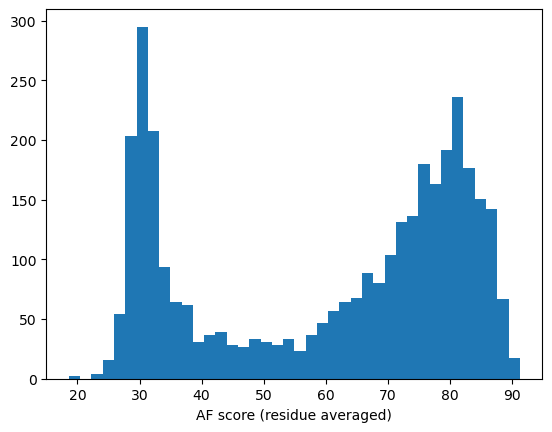

In [80]:
plt.hist(beta_residues, bins=40)
plt.xlabel("AF score (residue averaged)")

### Secondary structure and AF score

Plot by chain:

In [85]:
def plot_by_chain(chainID, ax=None):
    if ax is None:
        ax = plt.subplot(111)
    mask = chain_residue_masks[chainID]
    ax.plot(dssp_analysis.results.resids[mask], beta_residues[mask], label="AF score")
    ax.plot(dssp_analysis.results.resids[mask], 20 * loops[mask], label="loop")
    ax.set_xlabel(f"resid (chain {chainID})")
    ax.legend()
    return ax

<Axes: xlabel='resid (chain A)'>

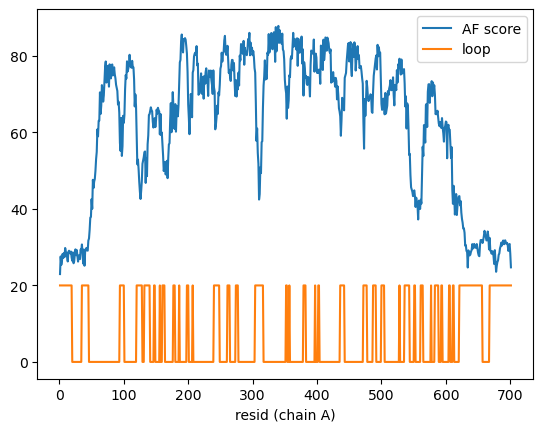

In [86]:
plot_by_chain("A")

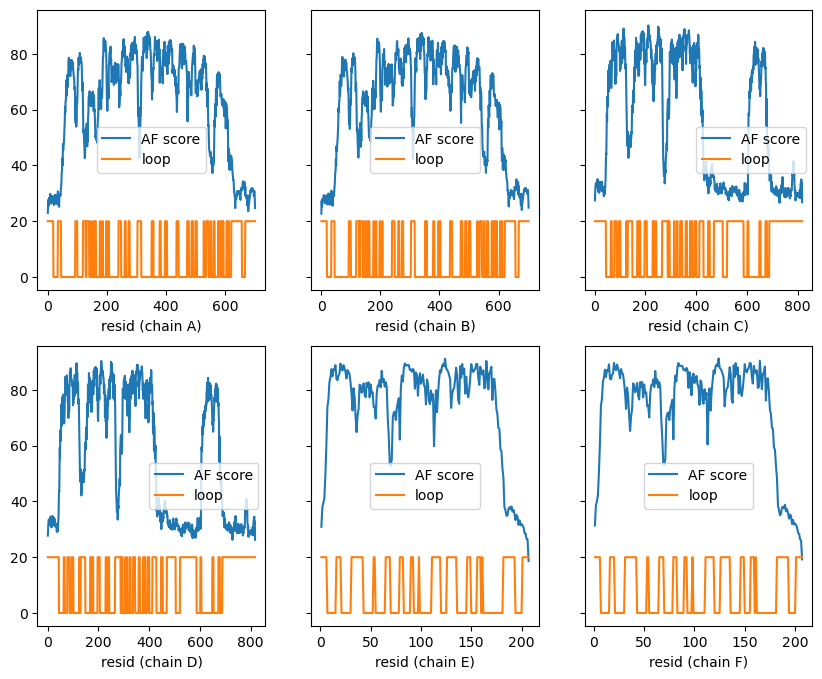

In [98]:
n_plots = len(chains)
ncols = 3
nrows = int(np.ceil(n_plots/ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=True, figsize=(10, 8))
chainIDs = sorted(chains.keys())
axs = np.ravel(axes)
for i, chainID in enumerate(chainIDs):
    ax = axs[i]
    plot_by_chain(chainID, ax=ax)

Looks as if the low scoring regions are mostly loops.

Let's try to just do a cutoff on score < 40:

### Trim by score only

In [99]:
keep = beta_residues >= 40

In [100]:
good_protein = protein.residues[keep]

In [104]:
box = good_protein.atoms.bbox()
L = 1.5 * (box[1] - box[0])  # add buffer
unitcell = [L[0], L[1], L[2], 90, 90, 90]

u.trajectory.ts.dimensions = unitcell

In [105]:
good_protein.atoms.write("NHE6_TBC1D5_highscore.pdb")

Visual inspection: This model removes too much of the interface.

Need to be more subtle and try to find long loops.

### Trim long loops

How to find long loop stretches?

In [106]:
loops

array([ True,  True,  True, ...,  True,  True,  True], shape=(3450,))

In [116]:
sloops = loops.astype(np.int8)

Find values where state changes

\begin{gather}
d_i = s_{i+1} - s_{i}
\end{gather}
with $d_i > 0$ indicating a change from "not loop" to "loop" and $d_i < 0$ change from "loop" to "not loop".

\begin{gather}
b = \{i+1 | d_i > 0\} \\
e = \{j | d_j < 0\}
\end{gather}


In [117]:
d = np.diff(sloops)

In [122]:
np.sum(d > 0), np.sum(d < 0)

(np.int64(153), np.int64(153))

The ends of loop stretches:

In [134]:
e = np.where(d < 0)[0]
e

array([  18,   44,   99,  127,  139,  147,  155,  162,  178,  185,  199,
        206,  247,  263,  276,  315,  352,  356,  381,  396,  402,  441,
        476,  490,  503,  527,  542,  551,  563,  576,  587,  593,  605,
        611,  655,  719,  745,  800,  828,  840,  848,  856,  863,  879,
        886,  900,  907,  948,  964,  977, 1016, 1053, 1057, 1082, 1097,
       1103, 1142, 1177, 1191, 1204, 1228, 1243, 1252, 1264, 1277, 1288,
       1294, 1306, 1312, 1356, 1445, 1468, 1487, 1502, 1527, 1549, 1575,
       1580, 1606, 1635, 1643, 1688, 1696, 1714, 1727, 1745, 1764, 1777,
       1785, 1801, 1829, 1854, 1905, 1987, 2006, 2054, 2079, 2262, 2285,
       2304, 2319, 2344, 2366, 2392, 2397, 2423, 2452, 2460, 2505, 2513,
       2525, 2531, 2544, 2562, 2581, 2594, 2602, 2618, 2646, 2671, 2722,
       2804, 2823, 2871, 2896, 3041, 3055, 3077, 3089, 3104, 3117, 3127,
       3133, 3154, 3170, 3184, 3194, 3196, 3228, 3248, 3262, 3284, 3296,
       3311, 3324, 3334, 3340, 3361, 3377, 3391, 34

The starts of stretches:

In [135]:
b = np.where(d > 0)[0] + 1
b

array([  34,   93,  119,  131,  146,  155,  159,  176,  185,  197,  206,
        239,  260,  273,  303,  351,  356,  378,  396,  401,  435,  471,
        486,  499,  527,  535,  550,  560,  576,  582,  592,  604,  610,
        620,  667,  735,  794,  819,  832,  847,  856,  860,  877,  886,
        898,  907,  940,  961,  974, 1004, 1052, 1057, 1079, 1097, 1102,
       1136, 1172, 1187, 1200, 1228, 1236, 1251, 1261, 1277, 1283, 1293,
       1305, 1311, 1321, 1368, 1465, 1479, 1496, 1526, 1532, 1569, 1580,
       1598, 1630, 1642, 1667, 1692, 1714, 1724, 1738, 1760, 1777, 1783,
       1795, 1814, 1848, 1871, 1923, 2003, 2050, 2074, 2089, 2282, 2296,
       2313, 2343, 2349, 2386, 2397, 2415, 2447, 2459, 2484, 2509, 2525,
       2531, 2541, 2555, 2577, 2594, 2600, 2612, 2631, 2665, 2688, 2740,
       2820, 2867, 2891, 2906, 3051, 3066, 3088, 3100, 3114, 3125, 3133,
       3146, 3161, 3181, 3191, 3196, 3217, 3236, 3258, 3273, 3295, 3307,
       3321, 3332, 3340, 3353, 3368, 3388, 3398, 34

In [131]:
loops[33:46]

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False])

In [136]:
loops[34:44+1]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [374]:
A = protein.select_atoms("chainID A")
start, stop = loop_stretches(A, loops)
start, stop

(array([  0,  34,  93, 119, 131, 146, 155, 159, 176, 185, 197, 206, 239,
        260, 273, 303, 351, 356, 378, 396, 401, 435, 471, 486, 499, 527,
        535, 550, 560, 576, 582, 592, 604, 610, 620, 667]),
 array([ 19,  45, 100, 128, 140, 148, 156, 163, 179, 186, 200, 207, 248,
        264, 277, 316, 353, 357, 382, 397, 403, 442, 477, 491, 504, 528,
        543, 552, 564, 577, 588, 594, 606, 612, 656, 701]))

Each stretch is now defined by a start:stop pair (a slice):

In [347]:
slices = np.transpose([start, stop])

For all chains

In [348]:
start = []
stop = []
for chainID in sorted(chains.keys()):
    chain = chains[chainID]
    print(chainID)
    _start, _stop = loop_stretches(chain, loops)
    start.extend(_start)
    stop.extend(_stop)
start = np.array(start)
stop = np.array(stop)

A
B
C
D
E
F


In [349]:
start, stop

(array([   0,   34,   93,  119,  131,  146,  155,  159,  176,  185,  197,
         206,  239,  260,  273,  303,  351,  356,  378,  396,  401,  435,
         471,  486,  499,  527,  535,  550,  560,  576,  582,  592,  604,
         610,  620,  667,  701,  735,  794,  819,  832,  847,  856,  860,
         877,  886,  898,  907,  940,  961,  974, 1004, 1052, 1057, 1079,
        1097, 1102, 1136, 1172, 1187, 1200, 1228, 1236, 1251, 1261, 1277,
        1283, 1293, 1305, 1311, 1321, 1368, 1402, 1465, 1479, 1496, 1526,
        1532, 1569, 1580, 1598, 1630, 1642, 1667, 1692, 1714, 1724, 1738,
        1760, 1777, 1783, 1795, 1814, 1848, 1871, 1923, 2003, 2050, 2074,
        2089, 2219, 2282, 2296, 2313, 2343, 2349, 2386, 2397, 2415, 2447,
        2459, 2484, 2509, 2525, 2531, 2541, 2555, 2577, 2594, 2600, 2612,
        2631, 2665, 2688, 2740, 2820, 2867, 2891, 2906, 3036, 3051, 3066,
        3088, 3100, 3114, 3125, 3133, 3146, 3161, 3181, 3191, 3196, 3217,
        3236, 3243, 3258, 3273, 3295, 

How long are the stretches and what is the length distribution?

In [350]:
length_loops = stop - start

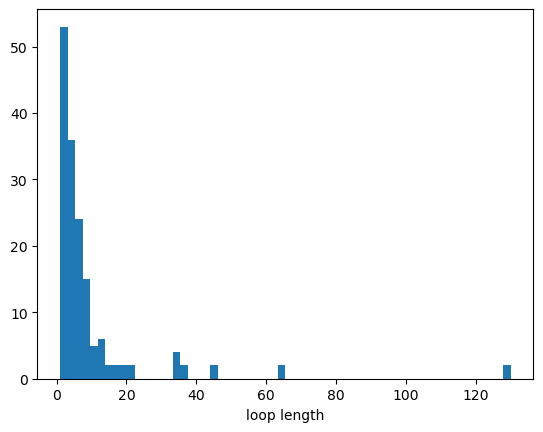

In [351]:
plt.hist(length_loops, bins=60)
plt.xlabel("loop length");

In [352]:
np.sort(length_loops)[::-1]

array([130, 130,  65,  65,  44,  44,  36,  36,  35,  35,  34,  34,  22,
        22,  19,  19,  18,  18,  16,  16,  13,  13,  12,  12,  12,  12,
        11,  11,  10,  10,  10,   9,   9,   9,   9,   9,   9,   9,   9,
         9,   9,   9,   8,   8,   8,   8,   7,   7,   7,   7,   7,   7,
         7,   7,   7,   7,   7,   7,   7,   7,   6,   6,   6,   6,   6,
         6,   6,   6,   6,   6,   5,   5,   5,   5,   5,   5,   5,   5,
         5,   5,   5,   5,   5,   5,   4,   4,   4,   4,   4,   4,   4,
         4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,   4,
         4,   4,   3,   3,   3,   3,   3,   3,   3,   3,   2,   2,   2,
         2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
         2,   2,   2,   2,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1])

In [353]:
length_cutoff = 18
remove = length_loops > length_cutoff

# build a mask for the original protein atomgroup where the long loops are False (to be removed) and the rest is True
keep = np.ones_like(loops, dtype=np.bool_)

slices = np.transpose([start, stop])

# bad code ...
for start_stop in slices[remove]:
    keep[slice(*start_stop)] = False

In [354]:
sum(keep == False)

np.int64(770)

In [355]:
sum(length_loops[remove])

np.int64(770)

In [356]:
protein_no_big_loops = protein.residues[keep].atoms

In [357]:
protein_no_big_loops.write("NHE6_TBC1D5_noloops18plus.pdb")

In [358]:
slices[remove]

array([[   0,   19],
       [ 620,  656],
       [ 667,  701],
       [ 701,  720],
       [1321, 1357],
       [1368, 1402],
       [1402, 1446],
       [1667, 1689],
       [1871, 1906],
       [1923, 1988],
       [2089, 2219],
       [2219, 2263],
       [2484, 2506],
       [2688, 2723],
       [2740, 2805],
       [2906, 3036]])

In [359]:
additional_keep = protein.residues[~keep].atoms.tempfactors > 40
additional_keep.sum()

np.int64(307)

In [360]:
protein_trimmed = protein.residues[keep].atoms + protein.residues[~keep].atoms[additional_keep].residues.atoms

In [361]:
protein_trimmed.write("NHE6_TBC1D5_noloops18plus_score40plus.pdb")

In [362]:
protein_trimmed.n_atoms, protein_no_big_loops.n_atoms

(21987, 21504)

The *NHE6_TBC1D5_noloops18plus_score40plus.pdb* seems to have everything needed (except GTP and Mg2+ ions).

Let's add GTP and MG2+ back, just so that we have it, too:

In [363]:
other = u.atoms - protein
model_trimmed = protein_trimmed + other

In [364]:
model_trimmed.write("NHE6_TBC1D5_GTP_MG_noloops18plus_score40plus.pdb")

### Improving workflow: identify problems and fix

G272:D and K276:D (and in C) are omitted from the model. Why?

In [371]:
rg = protein.select_atoms("resid 272 276 and chainID C D").residues
rg.ix

array([1673, 1677, 2490, 2494])

In [372]:
loops[1673-2:1677+2]

array([ True,  True,  True,  True,  True,  True,  True,  True])

In [378]:
C = protein.select_atoms("chainID C")
start, stop = loop_stretches(C, loops[first_resix:last_resix+1])
start, stop

(array([1402, 1465, 1479, 1496, 1526, 1532, 1569, 1580, 1598, 1630, 1642,
        1667, 1692, 1714, 1724, 1738, 1760, 1777, 1783, 1795, 1814, 1848,
        1871, 1923, 2003, 2050, 2074, 2089]),
 array([1446, 1469, 1488, 1503, 1528, 1550, 1576, 1581, 1607, 1636, 1644,
        1689, 1697, 1715, 1728, 1746, 1765, 1778, 1786, 1802, 1830, 1855,
        1906, 1988, 2007, 2055, 2080, 2219]))

In [380]:
loops[1667-1:1689+1]

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False])

In [381]:
beta_residues[1667-1:1689+1]

array([80.60454421, 74.96000163, 66.01714325, 53.16636311, 48.79444461,
       43.15999947, 40.2437501 , 37.82999992, 36.28777779, 37.3100001 ,
       40.68999958, 33.55444421, 36.00555505, 38.53285762, 37.3724997 ,
       41.54500055, 43.04428591, 44.80857195, 47.91875029, 48.12285723,
       45.35272737, 58.29000015, 60.10909098, 62.9342853 ])

In [382]:
beta_residues[rg.ix]

array([37.82999992, 33.55444421, 37.8125    , 33.48222224])

It looks as if the loop was first excluded but then some atoms were added _back_ because of relatively good scores.

When taking the score into account, we should decided _for a whole loop stretch_ if we want to put it back instead of doing this on an individual atom basis.

### Score loops and add "good" loops back

Let's calculate a per-loop score

* short loops should be likely to be included to maintain continuous chain
* long loops should likely be excluded

Let's try a simple average

$$
\Lambda_i = \frac{1}{|| \{r \in L_i\}||} \sum_{\{r \in L_i\}} \beta_r
$$

where $L_i$ is loop $i$ and $\beta_r$ is the AF score for residue $r$.

In [385]:
lambda_loops = np.zeros(len(slices), dtype=np.float64)
for i, (_start, _stop) in enumerate(slices):
    lambda_loops[i] = np.mean(beta_residues[_start:_stop])

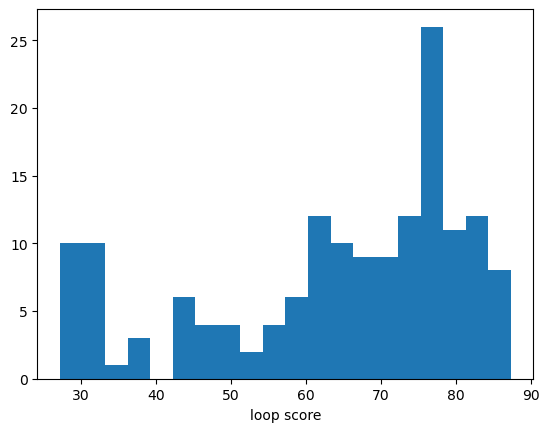

In [390]:
plt.hist(lambda_loops, bins=20)
plt.xlabel("loop score");

In [404]:
good_long_loops = (lambda_loops > 40) & (length_loops > 18)

In [406]:
good_long_loops.sum()

np.int64(2)

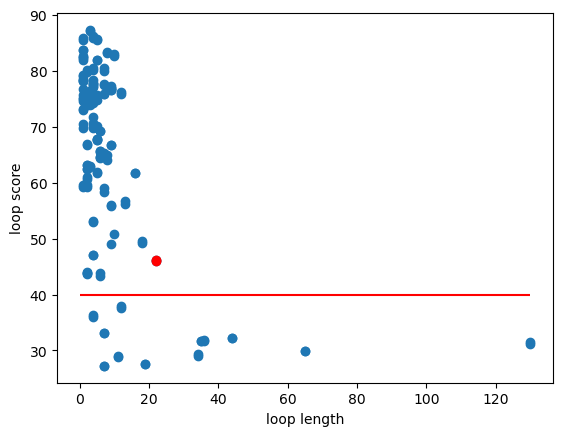

In [407]:
plt.scatter(length_loops, lambda_loops)
plt.xlabel("loop length")
plt.ylabel("loop score");
plt.hlines([40], xmin=0, xmax=length_loops.max(), color='r');

plt.scatter(length_loops[good_long_loops], lambda_loops[good_long_loops], color="r");

Long loops have low average scores (<40), so removing them is a good idea. Short loops generally have high scores, with a few exceptions.

We will add the two long loops with good score back.

## Workflow

The workflow trims poorly modelled loops
* remove all loops over a given length
* except keep loops with a loop score greater than a set cutoff

In [11]:
# calculate secondary structure and find loops
protein = u.select_atoms("protein")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)  # ignore that there's no time in PDB
    dssp_analysis = dssp.DSSP(protein).run()
loops = dssp_analysis.results.dssp_ndarray[0, :, 0]

In [22]:
# extract AF scores
beta_residues = np.array([beta.mean() for beta in protein.residues.tempfactors])

# compute loops on a per chain basis
start = []
stop = []
for chainID in sorted(chains.keys()):
    chain = chains[chainID]
    # print(chainID)
    _start, _stop = loop_stretches(chain, loops)
    start.extend(_start)
    stop.extend(_stop)
start = np.array(start)
stop = np.array(stop)

slices = np.transpose([start, stop])

length_loops = stop - start

# compute per-loop scores
lambda_loops = np.zeros(len(slices), dtype=np.float64)
for i, (_start, _stop) in enumerate(slices):
    lambda_loops[i] = np.mean(beta_residues[_start:_stop])

# selection of loops to remove
length_cutoff = 18
score_cutoff = 40

# (1) *remove* length > length_cutoff
remove = length_loops > length_cutoff

# (2) always *keep* loops with loop score >= score_cutoff
keep = lambda_loops >= score_cutoff

# Select loops for removal (~remove = keep_by_length)
# all_remove = ~(~remove | keep)
all_remove = remove & ~keep
all_keep = ~all_remove

# make the protein selection
# build a mask for the original protein residuegroup where the excluded loops are False (to be removed) and the rest is True
keep = np.ones_like(loops, dtype=np.bool_)

for start_stop in slices[all_remove]:
    keep[slice(*start_stop)] = False

protein_trimmed = protein.residues[keep].atoms


# summary output
def residue_identifier(res):
    resname = mda.lib.util.convert_aa_code(res.resname)
    return f"{res.atoms[0].chainID}:{resname}{res.resid}"
    
print(f"Removing {all_remove.sum()} loops. Keeping {all_keep.sum()} loops out of {len(length_loops)} loops.")
print(f"Lengths and scores of removed loops:")
table = []
for (_start, _stop), length, score in zip(slices[all_remove], length_loops[all_remove], lambda_loops[all_remove]):
    table.append((
        residue_identifier(protein.residues[_start]), 
        residue_identifier(protein.residues[_stop-1]),
        length, score))
print(tabulate.tabulate(table, headers=["first", "last", "length", "score"]))

Removing 14 loops. Keeping 145 loops out of 159 loops.
Lengths and scores of removed loops:
first    last      length    score
-------  ------  --------  -------
A:M1     A:P19         19  27.6531
A:S621   A:S656        36  31.6383
A:G668   A:A701        34  29.0752
B:M1     B:P19         19  27.5576
B:S621   B:S656        36  31.793
B:G668   B:A701        34  29.3571
C:M1     C:S44         44  32.175
C:S470   C:P504        35  31.6401
C:S522   C:S586        65  29.9537
C:E688   C:I817       130  31.4831
D:M1     D:S44         44  32.2066
D:S470   D:P504        35  31.7167
D:S522   D:S586        65  29.8764
D:E688   D:I817       130  31.2139


Let's add GTP and MG2+ back, just so that we have it, too:

In [23]:
other = u.atoms - protein
model_trimmed = protein_trimmed + other

In [24]:
# add bounding box for output
box = protein_trimmed.atoms.bbox()
L = 1.5 * (box[1] - box[0])  # add buffer
unitcell = [L[0], L[1], L[2], 90, 90, 90]

u.trajectory.ts.dimensions = unitcell

In [25]:
model_trimmed.write("NHE6_TBC1D5_GTP_MG_noloops18plus_score40plus.pdb")